In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from ydata_profiling import ProfileReport
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import zscore
import time
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
# HYPERPARAMTER TUNING:
RandomState = 42

In [3]:
data = pd.read_csv("C:\\Learning_ML\\ML_Projects\\Loan_Approval_Model\\loan_data_new.csv")
print(data.head())
# profile = ProfileReport(data, explorative=True)
# profile.to_file("report.html")

   Age  Gender    Education  Person Income  Employee Experience  \
0   22  female       Master          71948                    0   
1   21  female  High School          12282                    0   
2   25  female  High School          12438                    3   
3   23  female     Bachelor          79753                    0   
4   24    male       Master          66135                    1   

  Home Onwership  Loan Amount Loan Intent  Loan interest Rate  \
0           RENT        35000    PERSONAL               16.02   
1            OWN         1000   EDUCATION               11.14   
2       MORTGAGE         5500     MEDICAL               12.87   
3           RENT        35000     MEDICAL               15.23   
4           RENT        35000     MEDICAL               14.27   

   Loan percentage  Credit History  Credit Score Previous Loan  Loan Status  
0             0.49               3           561            No            1  
1             0.08               2           504  

In [4]:
TARGET = "Loan Status"
X = data.drop(columns=[TARGET])
Y = data[TARGET]
print(X.head())

   Age  Gender    Education  Person Income  Employee Experience  \
0   22  female       Master          71948                    0   
1   21  female  High School          12282                    0   
2   25  female  High School          12438                    3   
3   23  female     Bachelor          79753                    0   
4   24    male       Master          66135                    1   

  Home Onwership  Loan Amount Loan Intent  Loan interest Rate  \
0           RENT        35000    PERSONAL               16.02   
1            OWN         1000   EDUCATION               11.14   
2       MORTGAGE         5500     MEDICAL               12.87   
3           RENT        35000     MEDICAL               15.23   
4           RENT        35000     MEDICAL               14.27   

   Loan percentage  Credit History  Credit Score Previous Loan  
0             0.49               3           561            No  
1             0.08               2           504           Yes  
2          

In [5]:
# Identify column types automatically
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical columns:", cat_cols)
print("Numerical columns:", num_cols)


Categorical columns: ['Gender', 'Education', 'Home Onwership', 'Loan Intent', 'Previous Loan']
Numerical columns: ['Age', 'Person Income', 'Employee Experience', 'Loan Amount', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score']


In [6]:
data.describe()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [7]:
print(data['Age'].mode())

0    23
Name: Age, dtype: int64


In [8]:
print((data['Age'] == 21).sum())
print((data['Age'] == 22).sum()) # 22 has a large jump count after 21
print((data['Age'] == 23).sum()) # 23 has largest number of count
print((data['Age'] == 24).sum()) # 24 has second largest number of count
# 23 and 24 have maximum count and 22 has a large jump after 21. So we can say that the mode of age is 23 and 24.

1289
4236
5254
5138


In [9]:
print(data['Age'].median())

26.0


In [10]:
print(data['Age'].count())

45000


In [11]:
print((data['Age'] == 30).sum())
sum=0
for c in data['Age']:
    if c>=27 and c<=30:
        sum+=1
print(sum)

2021
10299


In [12]:
# to store unique values of education
res = [] 
for i in data['Education']:
    if i not in res:
        res.append(i)
print(res)

# to store count of each unique value of education
d = {} 
for i in res:
    d[i] = int((data['Education'] == i).sum())
print(d)

['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
{'Master': 6980, 'High School': 11972, 'Bachelor': 13399, 'Associate': 12028, 'Doctorate': 621}


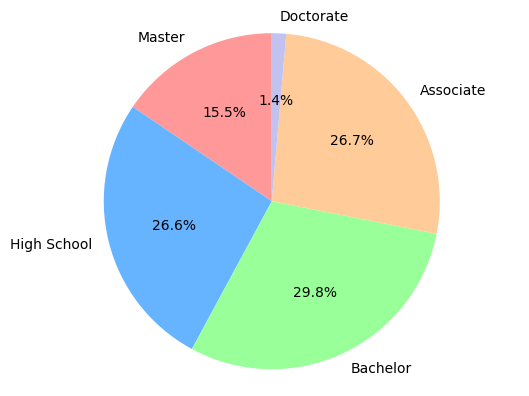

In [13]:
sizes = list(d.values())
labels = res

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99','#c2c2f0','#ffb3e6']
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.axis('equal')
plt.show(block=True)

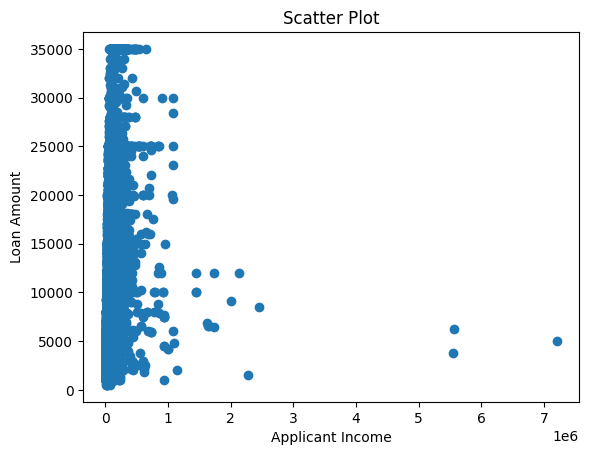

In [14]:
plt.scatter(data['Person Income'], data['Loan Amount'])
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.title('Scatter Plot')
plt.show()

# got few outliers in the scatter plot. So we can remove them by using IQR method.

In [15]:
d1 = data['Person Income'].sort_values(ascending=False).head(10)
print(d1)

32297    7200766
38113    5556399
37930    5545545
30049    2448661
32546    2280980
32497    2139143
37175    2012954
41288    1741243
31924    1728974
35850    1661567
Name: Person Income, dtype: int64


In [16]:
res = []
count = []
for i in data['Person Income']:
    if i <= 800000:
        res.append(i)
    else:
        count.append(i)
print(len(res))
print(len(count))

c = 0
for i in data['Person Income']:
    if i <= 10000:
        c += 1
print(c)

44954
46
31


(44954, 14)


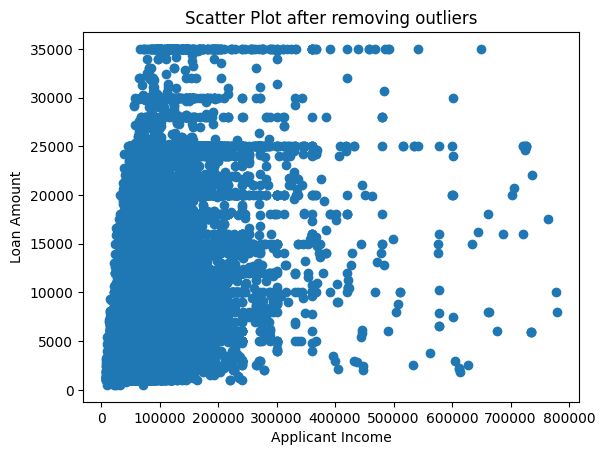

In [17]:
result_income = data[data['Person Income'] < 800000]
print(result_income.shape)
plt.scatter(result_income['Person Income'], result_income['Loan Amount'])
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.title('Scatter Plot after removing outliers')
plt.show()

In [18]:
# Using IQR method to remove outliers from the dataset. The IQR (Interquartile Range) is a measure of statistical dispersion and is
# calculated as the difference between the 75th percentile (Q3) and the 25th percentile (Q1) of the data. 
# Outliers are typically defined as data points that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.
Q1 = data['Person Income'].quantile(0.1)
Q3 = data['Person Income'].quantile(0.9)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[
    (data["Person Income"] < lower_bound) |
    (data["Person Income"] > upper_bound)
]
print(len(outliers))
arr = np.array(outliers)
print(arr.shape)
print(arr)

419
(419, 14)
[[23 'female' 'Master' ... 670 'Yes' 0]
 [25 'female' 'High School' ... 567 'Yes' 0]
 [26 'female' 'Associate' ... 669 'No' 0]
 ...
 [26 'male' 'Doctorate' ... 689 'No' 1]
 [29 'male' 'Master' ... 634 'No' 1]
 [42 'male' 'Doctorate' ... 689 'No' 1]]


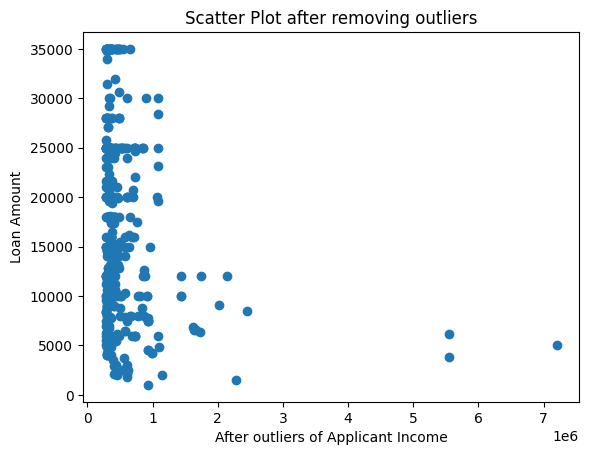

In [19]:
plt.scatter(outliers['Person Income'], outliers['Loan Amount'])
plt.xlabel('After outliers of Applicant Income')   
plt.ylabel('Loan Amount')
plt.title('Scatter Plot after removing outliers')
plt.show()

In [20]:
# Apply data preprocessing techniques such as scaling and encoding to prepare the data for modeling.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    ]
)

In [21]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=RandomState, stratify=Y)
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)
scale_pos_weight = (y_train == 1).sum() / (y_train == 0).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

Training set shape: (36000, 13)
Test set shape: (9000, 13)
Scale pos weight: 0.29


In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RandomState),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RandomState
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, eval_metric="logloss",
        scale_pos_weight=scale_pos_weight, n_jobs=-1, random_state=RandomState
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RandomState, verbose=-1
    ),
}

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RandomState)

In [24]:
results = {}
for model_name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    start = time.time()
    scores = cross_val_score(pipe, x_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    elapsed = time.time() - start
    results[model_name] = {"mean": scores.mean(), "std": scores.std(), "elapsed": elapsed}
    print(f"{model_name} - Mean ROC AUC: {scores.mean():.4f}, Std: {scores.std():.4f}, Elapsed Time: {elapsed:.4f} seconds")
best_model = max(results, key=lambda model: results[model]["mean"])
print(f"\nBest Model: {best_model} with Mean ROC AUC: {results[best_model]['mean']:.4f}, Elapsed Time: {results[best_model]['elapsed']:.2f} seconds")

Logistic Regression - Mean ROC AUC: 0.9536, Std: 0.0017, Elapsed Time: 19.6930 seconds
Random Forest - Mean ROC AUC: 0.9737, Std: 0.0019, Elapsed Time: 11.8028 seconds
XGBoost - Mean ROC AUC: 0.9767, Std: 0.0017, Elapsed Time: 4.2483 seconds
LightGBM - Mean ROC AUC: 0.9772, Std: 0.0016, Elapsed Time: 2.8949 seconds

Best Model: LightGBM with Mean ROC AUC: 0.9772, Elapsed Time: 2.89 seconds


In [25]:
if best_model == "XGBoost":
    tuned_model = XGBClassifier(eval_metric="logloss", scale_pos_weight=scale_pos_weight, n_jobs=-1, random_state=RandomState)
    param_dist = {
        "model__n_estimators": [200, 300, 500, 800],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__min_child_weight": [1, 3, 5],
    }
else:
    tuned_model = LGBMClassifier(class_weight="balanced", n_jobs=-1, random_state=RandomState, verbose=-1)
    param_dist = {
        "model__n_estimators": [200, 300, 500, 800],
        "model__max_depth": [-1, 4, 6, 8, 10],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__num_leaves": [15, 31, 63, 127],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
    }

In [26]:
pipe = Pipeline([("preprocess", preprocessor), ("model", tuned_model)])
search = RandomizedSearchCV(
    pipe, param_distributions=param_dist, n_iter=25, cv=cv,
    scoring="roc_auc", n_jobs=-1, random_state=RandomState, verbose=1
)
search.fit(x_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,Pipeline(step...verbose=-1))])
,param_distributions,"{'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [-1, 4, ...], 'model__n_estimators': [200, 300, ...], ...}"
,n_iter,25
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [27]:
print("\nBest CV AUC:", round(search.best_score_, 4))
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
 
best_pipe = search.best_estimator_


Best CV AUC: 0.9781
Best params:
  model__subsample: 1.0
  model__num_leaves: 127
  model__n_estimators: 200
  model__max_depth: -1
  model__learning_rate: 0.1
  model__colsample_bytree: 0.6


In [28]:
y_pred = best_pipe.predict(x_test)
y_proba = best_pipe.predict_proba(x_test)[:, 1]
 
print("\n" + "=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
 
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
 
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Rejected (0)", "Approved (1)"]))


FINAL EVALUATION ON TEST SET
Accuracy : 0.9316
Precision: 0.8246
Recall   : 0.8790
F1 Score : 0.8509
ROC-AUC  : 0.9794

Confusion Matrix:
[[6626  374]
 [ 242 1758]]

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.96      0.95      0.96      7000
Approved (1)       0.82      0.88      0.85      2000

    accuracy                           0.93      9000
   macro avg       0.89      0.91      0.90      9000
weighted avg       0.93      0.93      0.93      9000



In [ ]:
feature_names = (
    num_cols + list(best_pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(cat_cols))
)
importances = best_pipe.named_steps["model"].feature_importances_
 
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False).head(15)

print("\n" + "=" * 60)
print("TOP 15 MOST IMPORTANT FEATURES")
print("=" * 60)
print(importance_df.to_string(index=False))


TOP 15 MOST IMPORTANT FEATURES
                    feature  importance
              Person Income        5130
               Credit Score        3548
                Loan Amount        3278
         Loan interest Rate        2975
            Loan percentage        1962
                        Age        1776
             Credit History        1623
        Employee Experience        1600
        Home Onwership_RENT         526
                Gender_male         418
        Loan Intent_MEDICAL         332
         Education_Bachelor         318
       Loan Intent_PERSONAL         270
      Education_High School         245
Loan Intent_HOMEIMPROVEMENT         240


In [30]:
joblib.dump(best_pipe, "loan_model_pipeline.pkl")
print("\nSaved trained pipeline to loan_model_pipeline.pkl")


Saved trained pipeline to loan_model_pipeline.pkl
